<!--
  ============================================================================
  studentt_simulations.ipynb  —  reproducibility notebook
  Section 4.1 of the main manuscript and Section L.3 of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Student's-t Type I SSG Likelihood Simulations</h1>

<p align="center">
  <b>Reproducibility for Experiments E1 and E2 of Section 4.1 of the main manuscript and the ELBO trajectories of Supplementary Section L.3</b><br>
  <i>TAVIE-SSG vs. MFVI &middot; ADVI (mean-field &amp; full-rank) &middot; DADVI &middot; PyMC (NUTS)</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.9-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="PyMC" src="https://img.shields.io/badge/PyMC-5.x-1E4C7E">
  <img alt="JAX" src="https://img.shields.io/badge/JAX-x64-8A2BE2">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/student-t_simulations.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook comprises the Student's-$t$ Type I SSG likelihood experiments, namely

1. Experiments **E1** and **E2** in Section 4.1 of the main manuscript — MSEs of the
   parameter estimates, runtimes, and sliced-Wasserstein distances;
2. the **ELBO trajectory** plots in Section L.3 of the Supplementary Materials.

Data are simulated from a Student's-$t$ regression with known degrees of freedom, and
**TAVIE-SSG** is compared against five competitors over independent replicates.

| | Specification |
|:--|:--|
| **Model** | $y \sim \mathrm{StudentT}\!\left(\nu,\ \mu = X\boldsymbol\beta,\ \sigma = 1/\sqrt{\tau^{2}}\right)$ with $\nu$ known |
| **Truth** | $\tau^{2}_{0} = 3.0$, $\nu = 5$, $\boldsymbol\beta_{0}$ drawn from $\mathcal{N}(0, 1)$ |
| **Experiment E1** | fixed $p = 9$, $n \in \{200, 500, 1000, 2000\}$, 100 replicates |
| **Experiment E2** | fixed $n = 1000$, $p \in \{4, 9, 16, 21\}$, 100 replicates |
| **Methods** | TAVIE-SSG, MFVI, ADVI (MF), ADVI (FR), DADVI, PyMC (NUTS) |
| **Metrics** | $p^{-1}\lVert \boldsymbol\beta_0 - \hat{\boldsymbol\beta}\rVert_{2}^{2}$, $(\tau^{2}_0 - \hat{\tau}^{2})^2$, wall-clock runtime, and sliced-Wasserstein distance to the PyMC (NUTS) posterior |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| **Figure 4** | — | `Student_SW_MSE_boxplots_multi_n_p_8_1x3.pdf` |
| — | **Figure 10** | `Student_SW_boxplots_multi_n_p_8_logscale.pdf` |
| **Figure 5** | — | `Student_MSE_boxplots_multi_p_n_1000.pdf` |
| **Figures 1(a) and 1(b)** | — | `runtime_Student_multi_n_multi_p.pdf` |
| — | **Figure 22** (Section L.3) | `Student_ELBO_n_2000_p_8.pdf` |

All figures are written to `results_compete/plots/`, and the intermediate result files to
`results_compete/`.

### Required Imports for TAVIE-SSG and Competitors

In [ ]:
# imports required
# setup the dadvi module following https://github.com/martiningram/dadvi
import pymc as pm
import pytensor
import pytensor.tensor as pt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

### Student's-$t$ PyMC model and NUTS

In [ ]:
def student_t_pymc_model(X, y, nu, a0=0.05, b0=0.05):
    """
    Student's-t regression with known nu:
        y ~ StudentT(nu, mu = X @ beta, sigma = 1/sqrt(tau2))

    Priors:
        beta ~ Normal(0, 1)      (vector length p)
        tau2 ~ Gamma(a0/2, b0/2) [shape-rate]
    """
    # ensure arrays & shapes
    X = np.asarray(X)
    y = np.asarray(y)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n, p = X.shape
    dtype = np.dtype(pytensor.config.floatX)

    with pm.Model() as model:
        # data
        X_data = pm.MutableData("X", X.astype(dtype))
        y_data = pm.MutableData("y", y.astype(dtype))

        # priors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=p)
        tau2 = pm.Gamma("tau2", alpha=a0/2, beta=b0/2)   # precision

        # mean
        mu = pt.dot(X_data, beta)

        # Student-t likelihood with known nu
        pm.StudentT("y_obs", nu=nu, mu=mu, sigma=1 / pt.sqrt(tau2), observed=y_data)

    return model


def fit_NUTS_student_t(model):
    """
    Fit the Student's-t model with NUTS and return posterior means for beta and tau2.
    """
    import logging, warnings
    logging.getLogger("pymc").setLevel(logging.ERROR)
    logging.getLogger("pytensor").setLevel(logging.ERROR)
    warnings.filterwarnings("ignore", message=r"os\.fork\(\) was called", category=RuntimeWarning)

    # Fitting the NUTS model
    with model as model:
        nuts_model = pm.sample(progressbar=False, compute_convergence_checks=False)

    summ = az.summary(nuts_model, var_names=["beta", "tau2"])[["mean"]]

    # tau2 mean (scalar)
    tau2_mean = float(summ.loc[summ.index == "tau2", "mean"].values[0])

    # beta mean (scalar or vector)
    beta_rows = summ[summ.index.str.startswith("beta")]
    if len(beta_rows) == 1 and beta_rows.index[0] == "beta":
        beta_mean = float(beta_rows["mean"].iloc[0])
    else:
        def _idx(name):
            m = re.match(r"beta\[(\d+)\]", name)
            return int(m.group(1)) if m else 0
        beta_mean = (
            beta_rows.assign(_i=beta_rows.index.map(_idx))
                     .sort_values("_i")["mean"]
                     .to_numpy()
        )

    post_means = {"beta": np.array(beta_mean), "tau2": tau2_mean}
    return post_means

### Experiment E1: fixed $p=9$ (includes intercept) and $n\in \{200, 500, 1000, 2000\}$

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$ and $(\tau^{2}_0 - \hat{\tau}^{2})^2$. The results are stored in `results_compete/Student_metrics_multi_n_p_8.pkl`.

In [ ]:
# ==== Experiment settings ====
total_p = 9  # total_p = p + 1
p = 8
tau2_true = 3.0
df = 5
num_reps = 100
sample_sizes = [200, 500, 1000, 2000]     # <-- your various n’s here

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)
a, b = 0.025, 0.025

# Pre‐allocate storage: shape (len(sample_sizes), num_reps)
n_sizes = len(sample_sizes)
mse_beta_TAVIE          = np.zeros((n_sizes, num_reps))
mse_tau2_TAVIE          = np.zeros((n_sizes, num_reps))
time_TAVIE              = np.zeros((n_sizes, num_reps))

mse_beta_MFVI          = np.zeros((n_sizes, num_reps))
mse_tau2_MFVI          = np.zeros((n_sizes, num_reps))
time_MFVI              = np.zeros((n_sizes, num_reps))

mse_beta_DADVI          = np.zeros((n_sizes, num_reps))
mse_tau2_DADVI          = np.zeros((n_sizes, num_reps))
time_DADVI              = np.zeros((n_sizes, num_reps))

mse_beta_NUTS          = np.zeros((n_sizes, num_reps))
mse_tau2_NUTS          = np.zeros((n_sizes, num_reps))
time_NUTS              = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_mf           = np.zeros((n_sizes, num_reps))
mse_tau2_ADVI_mf           = np.zeros((n_sizes, num_reps))
time_ADVI_mf               = np.zeros((n_sizes, num_reps))

mse_beta_ADVI_fr   = np.zeros((n_sizes, num_reps))
mse_tau2_ADVI_fr   = np.zeros((n_sizes, num_reps))
time_ADVI_fr       = np.zeros((n_sizes, num_reps))

# Initialize TAVIE once
student_tavie_model = TAVIE_loc_scale(family="student", fit_intercept=True)

# ==== Main loops ====
for i, n in enumerate(sample_sizes):
    for rep in trange(num_reps, desc=f"n={n}"):
        np.random.seed(rep)
        # Generate synthetic data
        X = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack((np.ones(n), X))
        error =  np.random.standard_t(size = n, df = df) * 1/np.sqrt(tau2_true)
        y = beta_true[0] + X @ beta_true[1:len(beta_true)] + error

        # ---- TAVIE ----
        t0 = perf_counter()
        student_tavie_model.fit(X, y, nu=df, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE, tau2_est_TAVIE = student_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)
        mse_tau2_TAVIE[i, rep] = (tau2_est_TAVIE - tau2_true)**2

        # MFVI estimator
        t0 = perf_counter()
        beta_hat, sigma_sq_hat, nu_hat = MFVI_Student(X_bbvi, y, 
                                                      mu_beta=np.zeros(p+1), Sigma_beta=np.eye(p+1), 
                                                      A=2, B=2, nu_min=2.0, 
                                                      nu_max=20.0, tol=1e-6, verbose = False)
        time_MFVI[i, rep] = perf_counter() - t0
        beta_est2 = beta_hat
        tau2_est2 = 1/sigma_sq_hat
        mse_beta_MFVI[i, rep] = np.mean((beta_est2 - beta_true)**2)
        mse_tau2_MFVI[i, rep] = (tau2_est2 - tau2_true)**2

        # DADVI estimator
        student_dadvi_model = student_t_pymc_model(X_bbvi, y, nu=df)
        t0 = perf_counter()
        student_dadvi_res = fit_pymc_dadvi_with_jax(student_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = student_dadvi_res['beta']
        tau2_est_DADVI = np.exp(student_dadvi_res['tau2_log__'])
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
        mse_tau2_DADVI[i, rep] = (tau2_est_DADVI - tau2_true)**2
    
        # NUTS estimator
        t0 = perf_counter()
        student_nuts_res = fit_NUTS_student_t(student_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = student_nuts_res['beta']
        tau2_est_NUTS = student_nuts_res['tau2']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)
        mse_tau2_NUTS[i, rep] = (tau2_est_NUTS - tau2_true)**2

        # ADVI mean-field estimator
        t0 = perf_counter()
        res2 = BBVI_student_patience_best(X_bbvi, y, nu=df, a0=a, b0=b, lr=1e-3, patience=1e4, tol=1e-9, verbose=False)
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_est_ADVI_mf = res2['beta_mean']
        tau2_est_ADVI_mf = res2['tau2_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_est_ADVI_mf - beta_true)**2)
        mse_tau2_ADVI_mf[i, rep] = (tau2_est_ADVI_mf - tau2_true)**2

        # ADVI full-rank estimator
        t0 = perf_counter()
        res3 = BBVI_student_fullcov_AdamW_best(X_bbvi, y, nu=df, Sigma_prior=Sigma_prior, a0=a, b0=b, lr=1e-3, patience=1e4,
                                                          tol=1e-9, verbose=False)
        time_ADVI_fr[i, rep] = perf_counter() - t0
        beta_est_ADVI_fr = res3['beta_mean']
        tau2_est_ADVI_fr = res3['tau2_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_est_ADVI_fr - beta_true)**2)
        mse_tau2_ADVI_fr[i, rep] = (tau2_est_ADVI_fr - tau2_true)**2

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :       p,
    'n'            :       sample_sizes,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'mse_tau2_TAVIE':     mse_tau2_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_MFVI':     mse_beta_MFVI,
    'mse_tau2_MFVI':     mse_tau2_MFVI,
    'time_MFVI':         time_MFVI,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'mse_tau2_ADVI_mf':      mse_tau2_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'mse_tau2_ADVI_fr':      mse_tau2_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'mse_tau2_DADVI':      mse_tau2_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'mse_tau2_NUTS':      mse_tau2_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/Student_metrics_multi_n_p_{p}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Under Experiment E1, SW distance for Student's-$t$ Type I SSG likelihood

SW distance between PyMC (NUTS) approximation of the true posterior and TAVIE-SSG/MFVI/ADVI (MF)/ADVI (FR)/DADVI. Results are in `results_compete/sw_student_compare_methods_alpha_1.0_p_8.csv` and `results_compete/sw_student_compare_methods_alpha_1.0_p_8.pkl`.

In [2]:
# required imports
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from tqdm.auto import trange
import pymc as pm
import pytensor
import pytensor.tensor as pt
from matplotlib.patches import Patch
import jax
import jax.numpy as jnp
setattr(jnp, "product", jnp.prod)
jax.config.update("jax_enable_x64", True)
from CompetingMethods import *
from dadvi.pymc.jax_api import fit_pymc_dadvi_with_jax
from TAVIE import *
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
from time import perf_counter
from tqdm import tqdm, trange
from scipy.stats import t
import arviz as az
import re

In [ ]:
# ============================================================
# SETTINGS
# ============================================================
total_p = 9  # total_p = p + 1
p = 8
tau2_true = 3.0
df = 5
alpha = 1.0

num_reps = 10
sample_sizes = [200, 500, 1000, 2000]

Sigma_prior = np.eye(p + 1)
a0 = 0.025
b0 = 0.025

nuts_draws = 4000
nuts_tune = 1000
nuts_chains = 2
nuts_target_accept = 0.9
n_proj = 500

output_dir = "results_compete"
os.makedirs(output_dir, exist_ok=True)

np.random.seed(123)
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p + 1)


# ============================================================
# DATA GENERATION
# ============================================================
def generate_student_regression_data(n, p, beta_true, tau2_true, df, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    error = rng.standard_t(df=df, size=n) / np.sqrt(tau2_true)
    y = beta_true[0] + X @ beta_true[1:] + error
    return X, y


# ============================================================
# PYMC MODEL FOR TRUE POSTERIOR
# fixed nu = df
# ============================================================
def student_fractional_pymc_model(X, y, nu, alpha=1.0, prior_var=10.0, a0=0.005, b0=0.005):
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim == 1:
        X = X.reshape(-1, 1)

    n_local, p_local = X.shape
    X_with_intercept = np.column_stack((np.ones(n_local), X))

    dtype = np.dtype(pytensor.config.floatX)
    X_with_intercept = X_with_intercept.astype(dtype)
    y = y.astype(dtype)

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_with_intercept)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p_local + 1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        sigma = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def student_fractional_pymc_model_with_intercept_design(
    X_bbvi, y, nu, alpha=1.0, prior_var=10.0, a0=0.005, b0=0.005
):
    X_bbvi = np.asarray(X_bbvi)
    y = np.asarray(y)

    dtype = np.dtype(pytensor.config.floatX)
    X_bbvi = X_bbvi.astype(dtype)
    y = y.astype(dtype)

    n_local, p1 = X_bbvi.shape

    with pm.Model() as model:
        X_data = pm.Data("X_data", X_bbvi)
        y_data = pm.Data("y_data", y)

        beta = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=p1)
        tau2 = pm.Gamma("tau2", alpha=a0 / 2.0, beta=b0 / 2.0)

        mu = pt.dot(X_data, beta)
        sigma = 1.0 / pt.sqrt(tau2)

        loglik_vec = pm.logp(pm.StudentT.dist(nu=nu, mu=mu, sigma=sigma), y_data)
        pm.Potential("frac_loglik", alpha * pt.sum(loglik_vec))

    return model


def fit_NUTS_student_fractional(
    model,
    draws=4000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    random_seed=123
):
    with model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            target_accept=target_accept,
            progressbar=False,
            compute_convergence_checks=False,
            random_seed=random_seed,
            return_inferencedata=True
        )
    return idata


def extract_true_posterior_z_samples(idata):
    beta_draws = idata.posterior["beta"].stack(sample=("chain", "draw")).values
    tau2_draws = idata.posterior["tau2"].stack(sample=("chain", "draw")).values

    if beta_draws.shape[0] < beta_draws.shape[1]:
        beta_draws = beta_draws.T

    tau2_draws = np.asarray(tau2_draws).reshape(-1)
    log_tau2 = np.log(tau2_draws)

    return np.column_stack([beta_draws, log_tau2])


# ============================================================
# SLICED WASSERSTEIN
# ============================================================
def wasserstein_1d_sorted(x, y):
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))

    m = min(len(x), len(y))
    if len(x) != len(y):
        q = (np.arange(m) + 0.5) / m
        x = np.quantile(x, q)
        y = np.quantile(y, q)

    return np.mean(np.abs(x - y))


def sliced_wasserstein_distance(X, Y, n_proj=500, seed=123):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    d = X.shape[1]
    rng = np.random.default_rng(seed)

    dirs = rng.normal(size=(n_proj, d))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)

    sw_vals = np.empty(n_proj, dtype=float)
    for j in range(n_proj):
        v = dirs[j]
        sw_vals[j] = wasserstein_1d_sorted(X @ v, Y @ v)

    return float(np.mean(sw_vals))


# ============================================================
# TAVIE SAMPLING
# ============================================================
def sample_normal_gamma_z(m, V, a, b, n_mc, rng):
    m = np.asarray(m, dtype=float).reshape(-1)
    V = np.asarray(V, dtype=float)
    V = 0.5 * (V + V.T)

    jitter = 1e-10
    while True:
        try:
            L = np.linalg.cholesky(V + jitter * np.eye(V.shape[0]))
            break
        except np.linalg.LinAlgError:
            jitter *= 10
            if jitter > 1e-3:
                raise

    tau2 = rng.gamma(shape=a / 2.0, scale=2.0 / b, size=n_mc)
    z_std = rng.normal(size=(n_mc, len(m)))
    beta = m[None, :] + (z_std @ L.T) / np.sqrt(tau2)[:, None]
    log_tau2 = np.log(tau2)
    return np.column_stack([beta, log_tau2])


def fit_tavie_student_and_sample_z(X, y, nu, alpha, n_samples, seed=123):
    p_local = X.shape[1]
    prior_params = [np.zeros(p_local + 1), 10.0 * np.eye(p_local + 1), 0.005, 0.005]

    model = TAVIE_loc_scale(family="student", fit_intercept=True)
    model.fit(X, y, nu=nu, alpha=alpha, prior_params=prior_params, verbose=False)
    ve = model.get_variational_estimates()

    m_xi = np.asarray(ve["m_xi"], dtype=float)
    V_xi = np.asarray(ve["V_xi"], dtype=float)
    a_xi = float(ve["a_xi"])
    b_xi = float(ve["b_xi"])

    rng = np.random.default_rng(seed)
    return sample_normal_gamma_z(m_xi, V_xi, a_xi, b_xi, n_samples, rng)


# ============================================================
# MFVI STUDENT
# ============================================================
# ============================================================
# MFVI STUDENT
# Modified to return posterior hyperparameters
# and to generate posterior draws for SW computation
# ============================================================

# ============================================================
# sample from MFVI Student posterior for SW computation
# ============================================================
def sample_mfvi_student_z(beta_mean, beta_cov, tau2_shape, tau2_rate, n_samples, seed=123):
    """
    Draw samples from the MFVI Student posterior approximation:
        beta ~ N(beta_mean, beta_cov)
        tau2 ~ Gamma(tau2_shape, tau2_rate)

    Returns
    -------
    z : ndarray, shape (n_samples, p+1)
        z = (beta, log tau2)
    """
    rng = np.random.default_rng(seed)

    beta_mean = np.asarray(beta_mean, dtype=float).reshape(-1)
    beta_cov = np.asarray(beta_cov, dtype=float)
    beta_cov = 0.5 * (beta_cov + beta_cov.T)

    beta_draws = rng.multivariate_normal(mean=beta_mean, cov=beta_cov, size=n_samples)
    tau2_draws = rng.gamma(shape=tau2_shape, scale=1.0 / tau2_rate, size=n_samples)
    log_tau2_draws = np.log(tau2_draws)

    return np.column_stack([beta_draws, log_tau2_draws])


# ============================================================
# wrapper: fit MFVI Student and return posterior draws in z-space
# ============================================================
def fit_mfvi_student_and_sample_z(
    X_bbvi,
    y,
    n_samples,
    p,
    nu_fixed=5,
    seed=123,
    max_iter=500,
    tol=1e-6,
    verbose=False
):
    """
    Fits MFVI Student with fixed nu and returns:
      - z samples = (beta, log tau2)
      - fitted hyperparameter dictionary
    """
    res = MFVI_Student(
        X=X_bbvi,
        y=y,
        mu_beta=np.zeros(p + 1),
        Sigma_beta=np.eye(p + 1),
        A=2.0,
        B=2.0,
        nu_min=2.0,
        nu_max=20.0,
        max_iter=max_iter,
        tol=tol,
        nu_grid=500,
        fix_nu=nu_fixed,
        verbose=verbose
    )

    z = sample_mfvi_student_z(
        beta_mean=res["beta_mean"],
        beta_cov=res["beta_cov"],
        tau2_shape=res["tau2_shape"],
        tau2_rate=res["tau2_rate"],
        n_samples=n_samples,
        seed=seed
    )

    return z, res

def sample_student_advi_mf_z(q_mu, q_sd, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_sd = np.asarray(q_sd, dtype=float).reshape(-1)
    d = q_mu.shape[0]

    beta_draws = q_mu[None, :] + rng.normal(size=(n_samples, d)) * q_sd[None, :]
    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)
    return np.column_stack([beta_draws, np.log(tau2_draws)])


def fit_student_advi_mf_and_sample_z(X_bbvi, y, nu, a0, b0, n_samples, seed=123):
    res = BBVI_student_patience_best(
        X=X_bbvi, y=y, nu=nu, a0=a0, b0=b0,
        num_iters=20000, lr=1e-3, tol=1e-8, patience=1000,
        weight_decay=1e-2, verbose=False
    )
    z = sample_student_advi_mf_z(
        res["q_mu"], res["q_sd"], res["q_alpha_shape"], res["q_tau_rate"],
        n_samples=n_samples, seed=seed
    )
    return z, res

def sample_student_advi_fr_z(q_mu, q_L, q_alpha_shape, q_tau_rate, n_samples, seed=123):
    rng = np.random.default_rng(seed)

    q_mu = np.asarray(q_mu, dtype=float).reshape(-1)
    q_L = np.asarray(q_L, dtype=float)
    d = q_mu.shape[0]

    eps = rng.normal(size=(n_samples, d))
    beta_draws = q_mu[None, :] + eps @ q_L.T
    tau2_draws = rng.gamma(shape=q_alpha_shape, scale=1.0 / q_tau_rate, size=n_samples)

    return np.column_stack([beta_draws, np.log(tau2_draws)])


def fit_student_advi_fr_and_sample_z(X_bbvi, y, nu, Sigma_prior, a0, b0, n_samples, seed=123):
    res = BBVI_student_fullcov_AdamW_best(
        X=X_bbvi, y=y, nu=nu, Sigma_prior=Sigma_prior,
        a0=a0, b0=b0,
        num_iters=20000, lr=1e-3, tol=1e-8, patience=1000,
        weight_decay=1e-2, verbose=False
    )
    z = sample_student_advi_fr_z(
        res["q_mu"], res["q_L"], res["q_alpha_shape"], res["q_tau_rate"],
        n_samples=n_samples, seed=seed
    )
    return z, res


# ============================================================
# DADVI: Student
# ============================================================
def fit_student_dadvi_and_sample_z(pymc_model, n_samples, seed=123):
    dadvi_fit = fit_pymc_dadvi_with_jax(
        pymc_model,
        num_fixed_draws=30,
        seed=seed
    )

    dadvi_draws = dadvi_fit.get_posterior_draws_mean_field(
        n_draws=n_samples,
        seed=seed + 17
    )

    beta_draws = np.asarray(dadvi_draws["beta"], dtype=float)
    log_tau2_draws = np.asarray(dadvi_draws["tau2_log__"], dtype=float).reshape(-1)

    if beta_draws.ndim == 1:
        beta_draws = beta_draws.reshape(-1, 1)

    return np.column_stack([beta_draws, log_tau2_draws])


# ============================================================
# ONE REPLICATION
# ============================================================
def run_one_replication_student(
    n, rep, beta_true, p, tau2_true, df, alpha,
    nuts_draws=4000, nuts_tune=1000, nuts_chains=2, target_accept=0.9,
    n_proj=500
):
    seed_base = 1000 + 37 * rep + 101 * n

    X, y = generate_student_regression_data(
        n=n, p=p, beta_true=beta_true, tau2_true=tau2_true, df=df, seed=seed_base
    )
    X_bbvi = np.column_stack([np.ones(n), X])

    # --------------------------------------------------------
    # true posterior
    # --------------------------------------------------------
    pymc_model = student_fractional_pymc_model(
        X=X, y=y, nu=df, alpha=alpha, prior_var=10.0, a0=0.005, b0=0.005
    )

    t0 = perf_counter()
    idata = fit_NUTS_student_fractional(
        pymc_model,
        draws=nuts_draws, tune=nuts_tune, chains=nuts_chains,
        target_accept=target_accept, random_seed=seed_base
    )
    time_nuts = perf_counter() - t0

    z_true = extract_true_posterior_z_samples(idata)
    n_samples = z_true.shape[0]

    # --------------------------------------------------------
    # TAVIE
    # --------------------------------------------------------
    t0 = perf_counter()
    z_tavie = fit_tavie_student_and_sample_z(
        X=X, y=y, nu=df, alpha=alpha, n_samples=n_samples, seed=seed_base + 1
    )
    time_tavie = perf_counter() - t0
    sw_tavie = sliced_wasserstein_distance(z_true, z_tavie, n_proj=n_proj, seed=seed_base + 101)

    # --------------------------------------------------------
    # MFVI
    # --------------------------------------------------------
    t0 = perf_counter()
    mfvi_res = MFVI_Student(
        X=X_bbvi,
        y=y,
        mu_beta=np.zeros(p + 1),
        Sigma_beta=np.eye(p + 1),
        A=2.0,
        B=2.0,
        nu_min=2.0,
        nu_max=20.0,
        max_iter=500,
        tol=1e-6,
        nu_grid=500,
        fix_nu=df,           # important for apples-to-apples comparison
        verbose=False
    )
    z_mfvi = sample_mfvi_student_z(
        beta_mean=mfvi_res["beta_mean"],
        beta_cov=mfvi_res["beta_cov"],
        tau2_shape=mfvi_res["tau2_shape"],
        tau2_rate=mfvi_res["tau2_rate"],
        n_samples=n_samples,
        seed=seed_base + 2
    )
    time_mfvi = perf_counter() - t0
    sw_mfvi = sliced_wasserstein_distance(z_true, z_mfvi, n_proj=n_proj, seed=seed_base + 102)

    # --------------------------------------------------------
    # DADVI
    # --------------------------------------------------------
    student_dadvi_model = student_fractional_pymc_model_with_intercept_design(
        X_bbvi=X_bbvi, y=y, nu=df, alpha=alpha
    )

    t0 = perf_counter()
    z_dadvi = fit_student_dadvi_and_sample_z(
        pymc_model=student_dadvi_model, n_samples=n_samples, seed=seed_base + 3
    )
    time_dadvi = perf_counter() - t0
    sw_dadvi = sliced_wasserstein_distance(z_true, z_dadvi, n_proj=n_proj, seed=seed_base + 103)

    # --------------------------------------------------------
    # ADVI MF
    # --------------------------------------------------------
    t0 = perf_counter()
    z_advi_mf, _ = fit_student_advi_mf_and_sample_z(
        X_bbvi=X_bbvi, y=y, nu=df, a0=a0, b0=b0, n_samples=n_samples, seed=seed_base + 4
    )
    time_advi_mf = perf_counter() - t0
    sw_advi_mf = sliced_wasserstein_distance(z_true, z_advi_mf, n_proj=n_proj, seed=seed_base + 104)

    # --------------------------------------------------------
    # ADVI FR
    # --------------------------------------------------------
    t0 = perf_counter()
    z_advi_fr, _ = fit_student_advi_fr_and_sample_z(
        X_bbvi=X_bbvi, y=y, nu=df, Sigma_prior=Sigma_prior,
        a0=a0, b0=b0, n_samples=n_samples, seed=seed_base + 5
    )
    time_advi_fr = perf_counter() - t0
    sw_advi_fr = sliced_wasserstein_distance(z_true, z_advi_fr, n_proj=n_proj, seed=seed_base + 105)

    return {
        "n": n,
        "rep": rep,
        "alpha": alpha,
        "df": df,

        "sw_TAVIE": sw_tavie,
        "sw_MFVI": sw_mfvi,
        "sw_DADVI": sw_dadvi,
        "sw_ADVI_mf": sw_advi_mf,
        "sw_ADVI_fr": sw_advi_fr,

        "time_NUTS": time_nuts,
        "time_TAVIE": time_tavie,
        "time_MFVI": time_mfvi,
        "time_DADVI": time_dadvi,
        "time_ADVI_mf": time_advi_mf,
        "time_ADVI_fr": time_advi_fr,

        "num_true_samples": n_samples,
    }


# ============================================================
# RUN EXPERIMENT
# ============================================================
records = []

for n in sample_sizes:
    print(f"\nRunning n = {n}")
    for rep in trange(1, num_reps + 1, desc=f"n={n}"):
        out = run_one_replication_student(
            n=n,
            rep=rep,
            beta_true=beta_true,
            p=p,
            tau2_true=tau2_true,
            df=df,
            alpha=alpha,
            nuts_draws=nuts_draws,
            nuts_tune=nuts_tune,
            nuts_chains=nuts_chains,
            target_accept=nuts_target_accept,
            n_proj=n_proj
        )
        records.append(out)

results_df = pd.DataFrame(records)

csv_path = os.path.join(output_dir, f"sw_student_compare_methods_alpha_{alpha}_p_{p}.csv")
pkl_path = os.path.join(output_dir, f"sw_student_compare_methods_alpha_{alpha}_p_{p}.pkl")

results_df.to_csv(csv_path, index=False)
with open(pkl_path, "wb") as f:
    pickle.dump(records, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nSaved results to:\n{csv_path}\n{pkl_path}")

### Figure 4 in Main Manuscript

See: `results_compete/plots/Student_SW_MSE_boxplots_multi_n_p_8_1x3.pdf`.

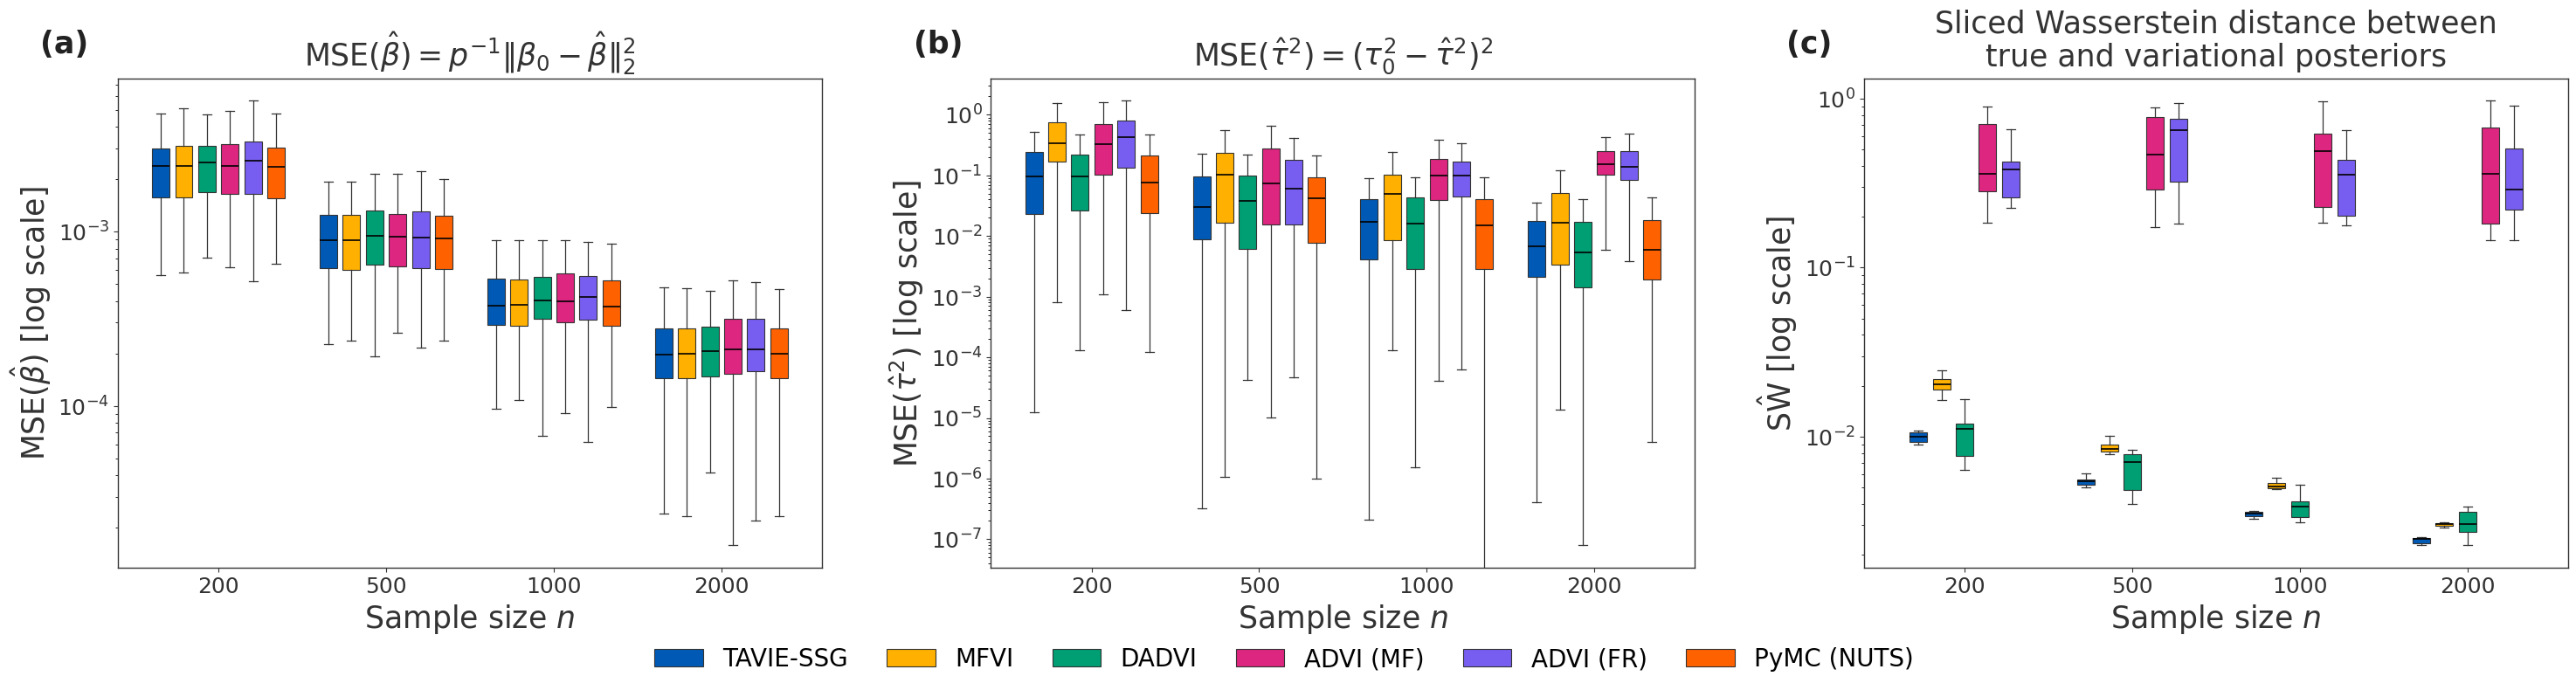

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "results_compete/plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_5_PATH = OUTPUT_DIR / "Student_SW_MSE_boxplots_multi_n_p_8_1x3.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED METHOD ORDER AND COLORS
# ============================================================

METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
    "PyMC (NUTS)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",    # vivid royal blue
    "MFVI": "#FFB000",         # golden amber
    "DADVI": "#009E73",        # emerald green
    "ADVI (MF)": "#DC267F",    # vibrant magenta
    "ADVI (FR)": "#785EF0",    # electric violet
    "PyMC (NUTS)": "#FE6100",  # vivid orange
}

METRIC_KEYS = {
    "TAVIE-SSG": {
        "beta": "mse_beta_TAVIE",
        "tau2": "mse_tau2_TAVIE",
    },
    "MFVI": {
        "beta": "mse_beta_MFVI",
        "tau2": "mse_tau2_MFVI",
    },
    "DADVI": {
        "beta": "mse_beta_DADVI",
        "tau2": "mse_tau2_DADVI",
    },
    "ADVI (MF)": {
        "beta": "mse_beta_ADVI_mf",
        "tau2": "mse_tau2_ADVI_mf",
    },
    "ADVI (FR)": {
        "beta": "mse_beta_ADVI_fr",
        "tau2": "mse_tau2_ADVI_fr",
    },
    "PyMC (NUTS)": {
        "beta": "mse_beta_NUTS",
        "tau2": "mse_tau2_NUTS",
    },
}


# ============================================================
# PLOTTING SETTINGS
# ============================================================

AXIS_COLOR = "#333333"

GROUP_SPACING = 2.4
METHOD_STEP = 0.33
BOX_WIDTH = 0.25

median_style = {
    "color": "black",
    "linewidth": 1.2,
}

whisker_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}

cap_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}


def style_axis(ax):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    ax.tick_params(
        axis="y",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color(AXIS_COLOR)
        spine.set_linewidth(1.0)


def draw_grouped_boxplots(
    ax,
    arrays_by_method,
    methods,
    x_values,
):
    """
    Draw grouped boxplots for a collection of methods.

    arrays_by_method[method][i] must contain the replicate
    values for x_values[i].
    """
    number_of_groups = len(x_values)
    number_of_methods = len(methods)

    centers = (
        np.arange(number_of_groups)
        * GROUP_SPACING
    )

    for method_index, method in enumerate(methods):
        method_values = arrays_by_method[method]

        data = [
            np.asarray(method_values[i], dtype=float)
            for i in range(number_of_groups)
        ]

        positions = (
            centers
            + (
                method_index
                - (number_of_methods - 1) / 2
            )
            * METHOD_STEP
        )

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in bp["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor=AXIS_COLOR,
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels(x_values)

    ax.set_xlim(
        centers[0] - GROUP_SPACING * 0.60,
        centers[-1] + GROUP_SPACING * 0.60,
    )

    style_axis(ax)


def make_legend_handles(methods=METHODS):
    return [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor=AXIS_COLOR,
            linewidth=0.8,
            label=method,
        )
        for method in methods
    ]


# ============================================================
# FIGURE 4
# Fixed p = 8 and varying sample size n
# Panels: beta MSE, tau^2 MSE, sliced Wasserstein distance
# ============================================================

metrics_n = pd.read_pickle(
    ROOT
    / "results_compete"
    / "Student_metrics_multi_n_p_8.pkl"
)

sample_sizes = np.asarray(metrics_n["n"])
p_fixed = int(metrics_n["p"])

beta_arrays_n = {
    method: np.asarray(
        metrics_n[METRIC_KEYS[method]["beta"]]
    )
    for method in METHODS
}

tau2_arrays_n = {
    method: np.asarray(
        metrics_n[METRIC_KEYS[method]["tau2"]]
    )
    for method in METHODS
}


# ------------------------------------------------------------
# Load the sliced Wasserstein results
# ------------------------------------------------------------

sw_records = pd.read_pickle(
    ROOT
    / "results_compete"
    / "sw_student_compare_methods_alpha_1.0_p_8.pkl"
)

sw_results = pd.DataFrame(sw_records)

SW_KEY_MAP = {
    "TAVIE-SSG": "sw_TAVIE",
    "MFVI": "sw_MFVI",
    "DADVI": "sw_DADVI",
    "ADVI (MF)": "sw_ADVI_mf",
    "ADVI (FR)": "sw_ADVI_fr",
}

SW_METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

sw_arrays_n = {}

for method in SW_METHODS:
    sw_key = SW_KEY_MAP[method]
    sw_arrays_n[method] = []

    for n_value in sample_sizes:
        values = sw_results.loc[
            sw_results["n"] == n_value,
            sw_key,
        ].dropna().to_numpy(dtype=float)

        # A logarithmic axis requires positive values.
        values = values[values > 0]

        sw_arrays_n[method].append(values)


# ------------------------------------------------------------
# Create Figure 4
# ------------------------------------------------------------

fig5, axes5 = plt.subplots(
    1,
    3,
    figsize=(30, 8),
    facecolor="white",
)


# Panel (a): beta MSE
draw_grouped_boxplots(
    ax=axes5[0],
    arrays_by_method=beta_arrays_n,
    methods=METHODS,
    x_values=sample_sizes,
)

axes5[0].set_yscale("log")

axes5[0].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[0].set_ylabel(
    r"MSE($\hat{\beta}$) [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[0].set_title(
    r"$\mathrm{MSE}(\hat{\beta})"
    r"=p^{-1}\|\beta_0-\hat{\beta}\|_2^2$",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (b): tau^2 MSE
draw_grouped_boxplots(
    ax=axes5[1],
    arrays_by_method=tau2_arrays_n,
    methods=METHODS,
    x_values=sample_sizes,
)

axes5[1].set_yscale("log")

axes5[1].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[1].set_ylabel(
    r"MSE($\hat{\tau}^2$) [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[1].set_title(
    r"$\mathrm{MSE}(\hat{\tau}^2)"
    r"=(\tau^2_0-\hat{\tau}^2)^2$",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (c): sliced Wasserstein distance
draw_grouped_boxplots(
    ax=axes5[2],
    arrays_by_method=sw_arrays_n,
    methods=SW_METHODS,
    x_values=sample_sizes,
)

axes5[2].set_yscale("log")

axes5[2].set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[2].set_ylabel(
    r"$\hat{\mathrm{SW}}$ [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

axes5[2].set_title(
    "Sliced Wasserstein distance between\n"
    "true and variational posteriors",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)


# ------------------------------------------------------------
# Figure 4 panel labels
# ------------------------------------------------------------

for ax, panel_label in zip(
    axes5,
    ["(a)", "(b)", "(c)"],
):
    ax.text(
        -0.11,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------
# Figure 4 shared legend
# ------------------------------------------------------------

fig5.legend(
    handles=make_legend_handles(),
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, 0.0),
    columnspacing=1.6,
    handlelength=2.0,
)

fig5.subplots_adjust(
    left=0.055,
    right=0.99,
    top=0.88,
    bottom=0.18,
    wspace=0.24,
)

fig5.savefig(
    FIGURE_5_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 10 in Supplementary Materials

See: `results_compete/plots/Student_SW_boxplots_multi_n_p_8_logscale.pdf`

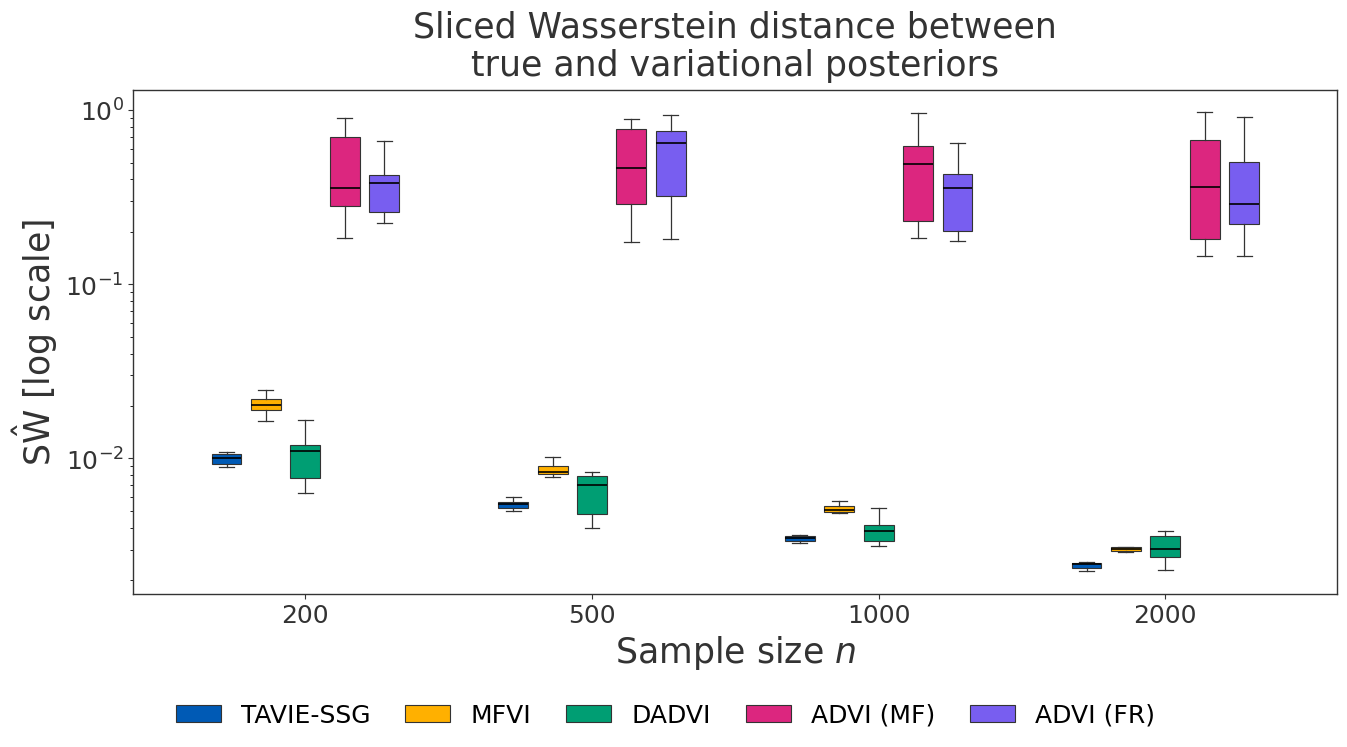

Figure saved to: /Users/somjit/Library/CloudStorage/OneDrive-TexasA&MUniversity/TAVIE/__TAVIE-SSG__/results_compete/plots/Student_SW_boxplots_multi_n_p_8_logscale.pdf


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================
ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run this code from the repository root."
)

OUTPUT_DIR = ROOT / "results_compete" / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_PATH = (
    OUTPUT_DIR
    / "Student_SW_boxplots_multi_n_p_8_logscale.pdf"
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# METHOD ORDER AND COLORS
# Panel (c) contains sliced-Wasserstein results for five methods
# ============================================================
SW_METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",
    "MFVI": "#FFB000",
    "DADVI": "#009E73",
    "ADVI (MF)": "#DC267F",
    "ADVI (FR)": "#785EF0",
}

SW_KEY_MAP = {
    "TAVIE-SSG": "sw_TAVIE",
    "MFVI": "sw_MFVI",
    "DADVI": "sw_DADVI",
    "ADVI (MF)": "sw_ADVI_mf",
    "ADVI (FR)": "sw_ADVI_fr",
}


# ============================================================
# PLOTTING SETTINGS
# ============================================================
AXIS_COLOR = "#333333"

GROUP_SPACING = 2.4
METHOD_STEP = 0.33
BOX_WIDTH = 0.25

median_style = {
    "color": "black",
    "linewidth": 1.2,
}

whisker_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}

cap_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}


def style_axis(ax):
    """Apply the formatting used in the original three-panel figure."""
    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    ax.tick_params(
        axis="y",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color(AXIS_COLOR)
        spine.set_linewidth(1.0)


def draw_grouped_boxplots(
    ax,
    arrays_by_method,
    methods,
    x_values,
):
    """
    Draw grouped boxplots.

    arrays_by_method[method][i] contains the replicate values
    corresponding to x_values[i].
    """
    number_of_groups = len(x_values)
    number_of_methods = len(methods)

    group_centers = (
        np.arange(number_of_groups)
        * GROUP_SPACING
    )

    for method_index, method in enumerate(methods):
        method_values = arrays_by_method[method]

        data = [
            np.asarray(method_values[i], dtype=float)
            for i in range(number_of_groups)
        ]

        positions = (
            group_centers
            + (
                method_index
                - (number_of_methods - 1) / 2
            )
            * METHOD_STEP
        )

        boxplot = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in boxplot["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor=AXIS_COLOR,
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(group_centers)
    ax.set_xticklabels(x_values)

    ax.set_xlim(
        group_centers[0] - GROUP_SPACING * 0.60,
        group_centers[-1] + GROUP_SPACING * 0.60,
    )

    style_axis(ax)


def make_legend_handles(methods):
    return [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor=AXIS_COLOR,
            linewidth=0.8,
            label=method,
        )
        for method in methods
    ]


# ============================================================
# LOAD SAMPLE-SIZE ORDER
# ============================================================
metrics_n = pd.read_pickle(
    ROOT
    / "results_compete"
    / "Student_metrics_multi_n_p_8.pkl"
)

sample_sizes = np.asarray(
    metrics_n["n"],
    dtype=int,
)

p_fixed = int(metrics_n["p"])

assert p_fixed == 8, (
    f"Expected p=8, but the result file contains p={p_fixed}."
)


# ============================================================
# LOAD SLICED-WASSERSTEIN RESULTS
# ============================================================
sw_records = pd.read_pickle(
    ROOT
    / "results_compete"
    / "sw_student_compare_methods_alpha_1.0_p_8.pkl"
)

sw_results = pd.DataFrame(sw_records)

sw_arrays_n = {}

for method in SW_METHODS:
    sw_key = SW_KEY_MAP[method]
    sw_arrays_n[method] = []

    for n_value in sample_sizes:
        values = (
            sw_results.loc[
                sw_results["n"] == n_value,
                sw_key,
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        # A logarithmic axis requires strictly positive values.
        values = values[
            np.isfinite(values) & (values > 0)
        ]

        if values.size == 0:
            raise ValueError(
                f"No positive finite values found for "
                f"{method} at n={n_value}."
            )

        sw_arrays_n[method].append(values)


# ============================================================
# GENERATE PANEL (c) AS A STANDALONE FIGURE
# ============================================================
fig, ax = plt.subplots(
    figsize=(14, 8),
    facecolor="white",
)

draw_grouped_boxplots(
    ax=ax,
    arrays_by_method=sw_arrays_n,
    methods=SW_METHODS,
    x_values=sample_sizes,
)

ax.set_yscale("log")

ax.set_xlabel(
    r"Sample size $n$",
    fontsize=25,
    color=AXIS_COLOR,
)

ax.set_ylabel(
    r"$\hat{\mathrm{SW}}$ [log scale]",
    fontsize=25,
    color=AXIS_COLOR,
)

ax.set_title(
    "Sliced Wasserstein distance between\n"
    "true and variational posteriors",
    fontsize=25,
    color=AXIS_COLOR,
    pad=10,
)

# Retain the original panel label.
ax.text(
    -0.09,
    1.04,
    "",
    transform=ax.transAxes,
    fontsize=25,
    fontweight="bold",
    verticalalignment="bottom",
    horizontalalignment="left",
    color="#222222",
)


# ============================================================
# LEGEND
# ============================================================
fig.legend(
    handles=make_legend_handles(SW_METHODS),
    loc="lower center",
    ncol=len(SW_METHODS),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.015),
    columnspacing=1.4,
    handlelength=1.8,
)


# ============================================================
# LAYOUT AND SAVE
# ============================================================
fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.84,
    bottom=0.21,
)

fig.savefig(
    FIGURE_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print(f"Figure saved to: {FIGURE_PATH}")

### Experiment E2: fixed $n=1000$ and $p\in \{4, 9, 16, 21\}$ (includes intercept)

Recording $p^{-1}\lVert \beta_0 - \hat{\beta}\rVert_{2}^{2}$ and $(\tau_0^{2} - \hat{\tau}^{2})^2$. The results are stored in `results_compete/Student_metrics_multi_p_n_1000.pkl`.

In [ ]:
# ==== Experiment settings ====
n = 1000
total_p_values = [4,9,16,21] # total_p_values = p_values + 1
p_values   = [3, 8, 15, 20]
tau2_true  = 3.0
df = 5
num_reps   = 100

# Hyperparameters for BBVI full‐covariances
a, b = 0.025, 0.025

# Pre‐allocate storage
P = len(p_values)
mse_beta_TAVIE        = np.zeros((P, num_reps))
mse_tau2_TAVIE        = np.zeros((P, num_reps))
time_TAVIE            = np.zeros((P, num_reps))

mse_beta_MFVI         = np.zeros((P, num_reps))
mse_tau2_MFVI        = np.zeros((P, num_reps))
time_MFVI            = np.zeros((P, num_reps))

mse_beta_DADVI        = np.zeros((P, num_reps))
mse_tau2_DADVI        = np.zeros((P, num_reps))
time_DADVI            = np.zeros((P, num_reps))

mse_beta_NUTS        = np.zeros((P, num_reps))
mse_tau2_NUTS        = np.zeros((P, num_reps))
time_NUTS            = np.zeros((P, num_reps))

mse_beta_ADVI_mf         = np.zeros((P, num_reps))
mse_tau2_ADVI_mf         = np.zeros((P, num_reps))
time_ADVI_mf             = np.zeros((P, num_reps))

mse_beta_ADVI_fr = np.zeros((P, num_reps))
mse_tau2_ADVI_fr = np.zeros((P, num_reps))
time_ADVI_fr     = np.zeros((P, num_reps))

# ==== Main loops over p and replicates ====
for i, p in enumerate(p_values):
    # Prior covariance for BBVI full-cov
    Sigma_prior = np.eye(p + 1)

    # Initialize TAVIE model once for this p
    student_tavie_model = TAVIE_loc_scale(family="student", fit_intercept=True)

    # Draw a fixed "true" beta for this p
    beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

    for rep in trange(num_reps, desc=f"p={p}"):
        np.random.seed(rep)
        # Generate synthetic data
        X = np.random.normal(size=(n, p))
        X_bbvi = np.column_stack((np.ones(n), X))
        error =  np.random.standard_t(size = n, df = df) * 1/np.sqrt(tau2_true)
        y = beta_true[0] + X @ beta_true[1:len(beta_true)] + error

        # ---- TAVIE ----
        t0 = perf_counter()
        student_tavie_model.fit(X, y, nu=df, verbose=False)
        time_TAVIE[i, rep] = perf_counter() - t0
        beta_est_TAVIE, tau2_est_TAVIE = student_tavie_model.get_TAVIE_means(verbose=False)
        mse_beta_TAVIE[i, rep] = np.mean((beta_est_TAVIE - beta_true)**2)
        mse_tau2_TAVIE[i, rep] = (tau2_est_TAVIE - tau2_true)**2

        # MFVI estimator
        t0 = perf_counter()
        beta_hat, sigma_sq_hat, nu_hat = MFVI_Student(X_bbvi, y, 
                                                      mu_beta=np.zeros(p+1), Sigma_beta=np.eye(p+1), 
                                                      A=2, B=2, nu_min=2.0, 
                                                      nu_max=20.0, tol=1e-6, verbose = False)
        time_MFVI[i, rep] = perf_counter() - t0
        beta_est2 = beta_hat
        tau2_est2 = 1/sigma_sq_hat
        mse_beta_MFVI[i, rep] = np.mean((beta_est2 - beta_true)**2)
        mse_tau2_MFVI[i, rep] = (tau2_est2 - tau2_true)**2

        # DADVI estimator
        student_dadvi_model = student_t_pymc_model(X_bbvi, y, nu=df)
        t0 = perf_counter()
        student_dadvi_res = fit_pymc_dadvi_with_jax(student_dadvi_model, num_fixed_draws=30).get_posterior_means()
        time_DADVI[i, rep] = perf_counter() - t0
        beta_est_DADVI = student_dadvi_res['beta']
        tau2_est_DADVI = np.exp(student_dadvi_res['tau2_log__'])
        mse_beta_DADVI[i, rep] = np.mean((beta_est_DADVI - beta_true)**2)
        mse_tau2_DADVI[i, rep] = (tau2_est_DADVI - tau2_true)**2
    
        # NUTS estimator
        t0 = perf_counter()
        student_nuts_res = fit_NUTS_student_t(student_dadvi_model)
        time_NUTS[i, rep] = perf_counter() - t0
        beta_est_NUTS = student_nuts_res['beta']
        tau2_est_NUTS = student_nuts_res['tau2']
        mse_beta_NUTS[i, rep] = np.mean((beta_est_NUTS - beta_true)**2)
        mse_tau2_NUTS[i, rep] = (tau2_est_NUTS - tau2_true)**2

        # ADVI mean-field estimator
        t0 = perf_counter()
        res2 = BBVI_student_patience_best(X_bbvi, y, nu=df, a0=a, b0=b, lr=1e-3, patience=1e4, tol=1e-9, verbose=False)
        time_ADVI_mf[i, rep] = perf_counter() - t0
        beta_est_ADVI_mf = res2['beta_mean']
        tau2_est_ADVI_mf = res2['tau2_mean']
        mse_beta_ADVI_mf[i, rep] = np.mean((beta_est_ADVI_mf - beta_true)**2)
        mse_tau2_ADVI_mf[i, rep] = (tau2_est_ADVI_mf - tau2_true)**2

        # ADVI full-rank estimator
        t0 = perf_counter()
        res3 = BBVI_student_fullcov_AdamW_best(X_bbvi, y, nu=df, Sigma_prior=Sigma_prior, a0=a, b0=b, lr=1e-3, patience=1e4,
                                                          tol=1e-9, verbose=False)
        time_ADVI_fr[i, rep] = perf_counter() - t0
        beta_est_ADVI_fr = res3['beta_mean']
        tau2_est_ADVI_fr = res3['tau2_mean']
        mse_beta_ADVI_fr[i, rep] = np.mean((beta_est_ADVI_fr - beta_true)**2)
        mse_tau2_ADVI_fr[i, rep] = (tau2_est_ADVI_fr - tau2_true)**2

        

# saving the metrics
import pickle

# collect everything into a single dict
metrics_df = {
    'p'            :      p_values,
    'n'            :      n,
    'mse_beta_TAVIE':     mse_beta_TAVIE,
    'mse_tau2_TAVIE':     mse_tau2_TAVIE,
    'time_TAVIE':         time_TAVIE,
    'mse_beta_MFVI':     mse_beta_MFVI,
    'mse_tau2_MFVI':     mse_tau2_MFVI,
    'time_MFVI':         time_MFVI,
    'mse_beta_ADVI_mf':      mse_beta_ADVI_mf,
    'mse_tau2_ADVI_mf':      mse_tau2_ADVI_mf,
    'time_ADVI_mf':          time_ADVI_mf,
    'mse_beta_ADVI_fr':      mse_beta_ADVI_fr,
    'mse_tau2_ADVI_fr':      mse_tau2_ADVI_fr,
    'time_ADVI_fr':          time_ADVI_fr,
    'mse_beta_DADVI':      mse_beta_DADVI,
    'mse_tau2_DADVI':      mse_tau2_DADVI,
    'time_DADVI':          time_DADVI,
    'mse_beta_NUTS':      mse_beta_NUTS,
    'mse_tau2_NUTS':      mse_tau2_NUTS,
    'time_NUTS':          time_NUTS,
}

# write to disk
with open(f'results_compete/Student_metrics_multi_p_n_{n}.pkl', 'wb') as f:
    pickle.dump(metrics_df, f, protocol=pickle.HIGHEST_PROTOCOL)

### Figure 5 in Main Manuscript

See: `results_compete/plots/Student_MSE_boxplots_multi_p_n_1000.pdf`.

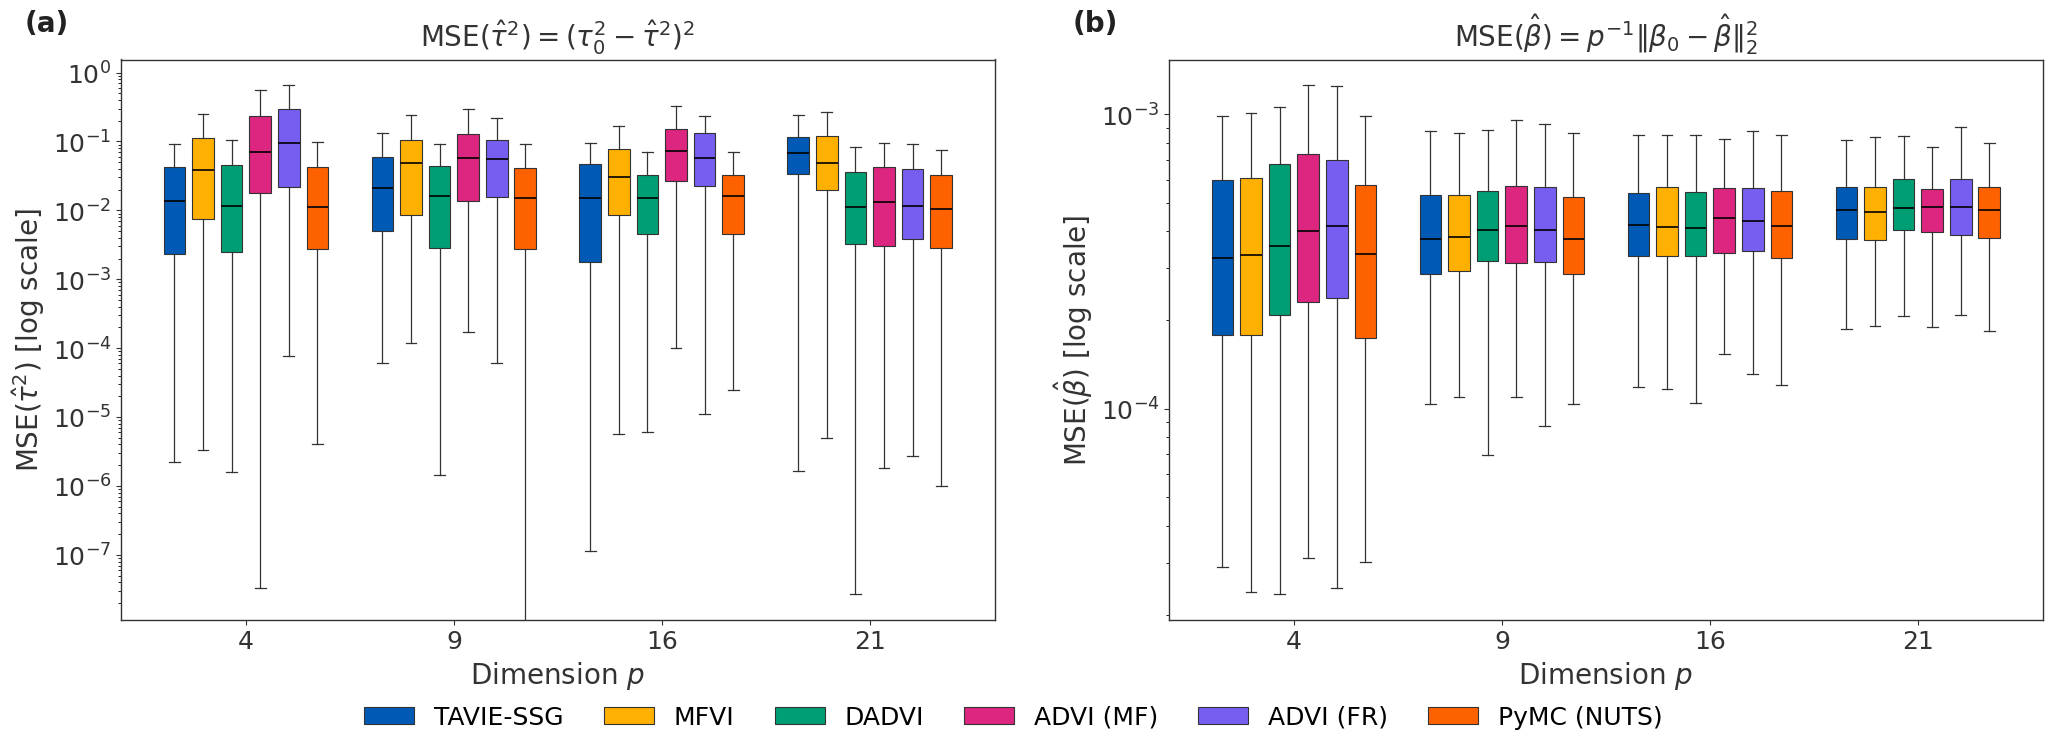

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run final_figures.ipynb from the repository root."
)

OUTPUT_DIR = ROOT / "results_compete/plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_6_PATH = OUTPUT_DIR / "Student_MSE_boxplots_multi_p_n_1000.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED METHOD ORDER AND COLORS
# ============================================================

METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
    "PyMC (NUTS)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",    # vivid royal blue
    "MFVI": "#FFB000",         # golden amber
    "DADVI": "#009E73",        # emerald green
    "ADVI (MF)": "#DC267F",    # vibrant magenta
    "ADVI (FR)": "#785EF0",    # electric violet
    "PyMC (NUTS)": "#FE6100",  # vivid orange
}

METRIC_KEYS = {
    "TAVIE-SSG": {
        "beta": "mse_beta_TAVIE",
        "tau2": "mse_tau2_TAVIE",
    },
    "MFVI": {
        "beta": "mse_beta_MFVI",
        "tau2": "mse_tau2_MFVI",
    },
    "DADVI": {
        "beta": "mse_beta_DADVI",
        "tau2": "mse_tau2_DADVI",
    },
    "ADVI (MF)": {
        "beta": "mse_beta_ADVI_mf",
        "tau2": "mse_tau2_ADVI_mf",
    },
    "ADVI (FR)": {
        "beta": "mse_beta_ADVI_fr",
        "tau2": "mse_tau2_ADVI_fr",
    },
    "PyMC (NUTS)": {
        "beta": "mse_beta_NUTS",
        "tau2": "mse_tau2_NUTS",
    },
}


# ============================================================
# PLOTTING SETTINGS
# ============================================================

AXIS_COLOR = "#333333"

GROUP_SPACING = 2.4
METHOD_STEP = 0.33
BOX_WIDTH = 0.25

median_style = {
    "color": "black",
    "linewidth": 1.2,
}

whisker_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}

cap_style = {
    "color": AXIS_COLOR,
    "linewidth": 0.9,
}


def style_axis(ax):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="x",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    ax.tick_params(
        axis="y",
        colors=AXIS_COLOR,
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color(AXIS_COLOR)
        spine.set_linewidth(1.0)


def draw_grouped_boxplots(
    ax,
    arrays_by_method,
    methods,
    x_values,
):
    """
    Draw grouped boxplots for a collection of methods.

    arrays_by_method[method][i] must contain the replicate
    values for x_values[i].
    """
    number_of_groups = len(x_values)
    number_of_methods = len(methods)

    centers = (
        np.arange(number_of_groups)
        * GROUP_SPACING
    )

    for method_index, method in enumerate(methods):
        method_values = arrays_by_method[method]

        data = [
            np.asarray(method_values[i], dtype=float)
            for i in range(number_of_groups)
        ]

        positions = (
            centers
            + (
                method_index
                - (number_of_methods - 1) / 2
            )
            * METHOD_STEP
        )

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in bp["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor=AXIS_COLOR,
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels(x_values)

    ax.set_xlim(
        centers[0] - GROUP_SPACING * 0.60,
        centers[-1] + GROUP_SPACING * 0.60,
    )

    style_axis(ax)


def make_legend_handles(methods=METHODS):
    return [
        Patch(
            facecolor=METHOD_COLORS[method],
            edgecolor=AXIS_COLOR,
            linewidth=0.8,
            label=method,
        )
        for method in methods
    ]


# ============================================================
# FIGURE 5
# Fixed n = 1000 and varying dimension p
# Panels: tau^2 MSE and beta MSE
# ============================================================

metrics_p = pd.read_pickle(
    ROOT
    / "results_compete"
    / "Student_metrics_multi_p_n_1000.pkl"
)

p_values = np.asarray(metrics_p["p"])
n_fixed = int(metrics_p["n"])

beta_arrays_p = {
    method: np.asarray(
        metrics_p[METRIC_KEYS[method]["beta"]]
    )
    for method in METHODS
}

tau2_arrays_p = {
    method: np.asarray(
        metrics_p[METRIC_KEYS[method]["tau2"]]
    )
    for method in METHODS
}


# ------------------------------------------------------------
# Create Figure 5
# ------------------------------------------------------------

fig6, axes6 = plt.subplots(
    1,
    2,
    figsize=(21, 8),
    facecolor="white",
)


# Panel (a): tau^2 MSE
draw_grouped_boxplots(
    ax=axes6[0],
    arrays_by_method=tau2_arrays_p,
    methods=METHODS,
    x_values=np.array(p_values)+1,
)

axes6[0].set_yscale("log")

axes6[0].set_xlabel(
    r"Dimension $p$",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[0].set_ylabel(
    r"MSE($\hat{\tau}^2$) [log scale]",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[0].set_title(
    r"$\mathrm{MSE}(\hat{\tau}^2)"
    r"=(\tau^2_0-\hat{\tau}^2)^2$",
    fontsize=20,
    color=AXIS_COLOR,
    pad=10,
)


# Panel (b): beta MSE
draw_grouped_boxplots(
    ax=axes6[1],
    arrays_by_method=beta_arrays_p,
    methods=METHODS,
    x_values=np.array(p_values)+1,
)

axes6[1].set_yscale("log")

axes6[1].set_xlabel(
    r"Dimension $p$",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[1].set_ylabel(
    r"MSE($\hat{\beta}$) [log scale]",
    fontsize=20,
    color=AXIS_COLOR,
)

axes6[1].set_title(
    r"$\mathrm{MSE}(\hat{\beta})"
    r"=p^{-1}\|\beta_0-\hat{\beta}\|_2^2$",
    fontsize=20,
    color=AXIS_COLOR,
    pad=10,
)


# ------------------------------------------------------------
# Figure 5 panel labels
# ------------------------------------------------------------

for ax, panel_label in zip(
    axes6,
    ["(a)", "(b)"],
):
    ax.text(
        -0.11,
        1.04,
        panel_label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ------------------------------------------------------------
# Figure 5 shared legend
# ------------------------------------------------------------

fig6.legend(
    handles=make_legend_handles(),
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.015),
    columnspacing=1.6,
    handlelength=2.0,
)

fig6.subplots_adjust(
    left=0.075,
    right=0.99,
    top=0.88,
    bottom=0.18,
    wspace=0.20,
)

fig6.savefig(
    FIGURE_6_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### Figure 1(a) and 1(b) in Main Manuscript

See: `results_compete/plots/runtime_Student_multi_n_multi_p.pdf`

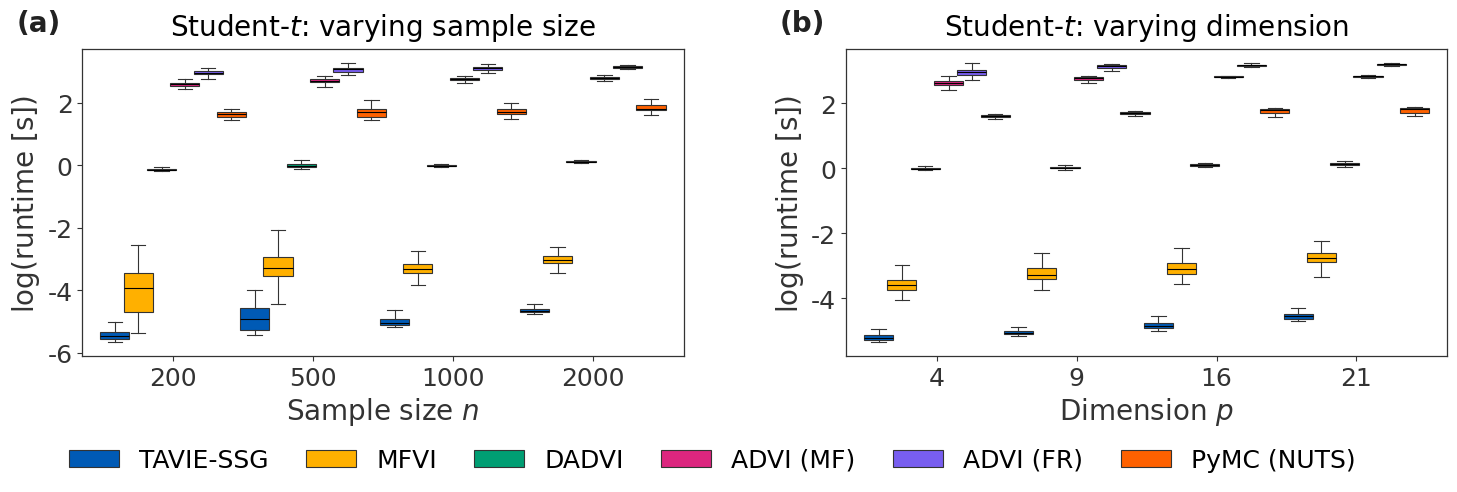

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PATHS AND GLOBAL STYLE
# ============================================================

ROOT = Path.cwd()

assert (ROOT / "results_compete").exists(), (
    "Run this code from the repository root."
)

OUTPUT_DIR = ROOT / "results_compete/plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "runtime_Student_multi_n_multi_p.pdf"

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# SHARED METHOD ORDER AND COLORS
# ============================================================

METHODS = [
    "TAVIE-SSG",
    "MFVI",
    "DADVI",
    "ADVI (MF)",
    "ADVI (FR)",
    "PyMC (NUTS)",
]

METHOD_COLORS = {
    "TAVIE-SSG": "#005AB5",
    "MFVI": "#FFB000",
    "DADVI": "#009E73",
    "ADVI (MF)": "#DC267F",
    "ADVI (FR)": "#785EF0",
    "PyMC (NUTS)": "#FE6100",
}

RUNTIME_KEYS = {
    "TAVIE-SSG": "time_TAVIE",
    "MFVI": "time_MFVI",
    "DADVI": "time_DADVI",
    "ADVI (MF)": "time_ADVI_mf",
    "ADVI (FR)": "time_ADVI_fr",
    "PyMC (NUTS)": "time_NUTS",
}


# ============================================================
# LOAD STUDENT-t RESULTS
# ============================================================

metrics_n = pd.read_pickle(
    ROOT / "results_compete/Student_metrics_multi_n_p_8.pkl"
)

metrics_p = pd.read_pickle(
    ROOT / "results_compete/Student_metrics_multi_p_n_1000.pkl"
)

sample_sizes = np.asarray(metrics_n["n"])
p_values = np.asarray(metrics_p["p"])

runtime_arrays_n = {
    method: np.asarray(metrics_n[key])
    for method, key in RUNTIME_KEYS.items()
}

runtime_arrays_p = {
    method: np.asarray(metrics_p[key])
    for method, key in RUNTIME_KEYS.items()
}

for method in METHODS:
    assert runtime_arrays_n[method].shape[0] == len(sample_sizes)
    assert runtime_arrays_p[method].shape[0] == len(p_values)


# ============================================================
# PLOTTING SETTINGS
# ============================================================

EPS = 1e-16
GROUP_SPACING = 2.4
METHOD_STEP = 0.40
BOX_WIDTH = 0.50

median_style = {
    "color": "black",
    "linewidth": 0.8,
}

whisker_style = {
    "color": "#333333",
    "linewidth": 0.8,
}

cap_style = {
    "color": "#333333",
    "linewidth": 0.8,
}


def style_axis(ax):
    ax.set_facecolor("white")

    ax.tick_params(
        axis="both",
        colors="#333333",
        labelsize=18,
    )

    for spine in ax.spines.values():
        spine.set_color("#333333")
        spine.set_linewidth(0.9)


def add_student_runtime_panel(
    ax,
    runtime_arrays,
    x_values,
    xlabel,
):
    centers = np.arange(len(x_values)) * GROUP_SPACING

    for j, method in enumerate(METHODS):
        arr = np.asarray(runtime_arrays[method])

        data = [
            np.log(np.clip(arr[i, :], EPS, None))
            for i in range(len(x_values))
        ]

        positions = (
            centers
            + (j - (len(METHODS) - 1) / 2) * METHOD_STEP
        )

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=BOX_WIDTH,
            patch_artist=True,
            showfliers=False,
            medianprops=median_style,
            whiskerprops=whisker_style,
            capprops=cap_style,
        )

        for box in bp["boxes"]:
            box.set(
                facecolor=METHOD_COLORS[method],
                edgecolor="#333333",
                linewidth=0.8,
                alpha=1.0,
            )

    ax.set_xticks(centers)
    ax.set_xticklabels(x_values)

    ax.set_xlabel(
        xlabel,
        fontsize=20,
        color="#333333",
    )

    ax.set_ylabel(
        r"$\log(\mathrm{runtime}\ [\mathrm{s}])$",
        fontsize=20,
        color="#333333",
    )

    ax.set_xlim(
        centers[0] - GROUP_SPACING * 0.65,
        centers[-1] + GROUP_SPACING * 0.65,
    )

    style_axis(ax)


# ============================================================
# CREATE THE 1 x 2 FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 4.2),
    facecolor="white",
)


# ============================================================
# PANEL (a): RUNTIME VERSUS SAMPLE SIZE
# ============================================================

add_student_runtime_panel(
    ax=axes[0],
    runtime_arrays=runtime_arrays_n,
    x_values=sample_sizes,
    xlabel=r"Sample size $n$",
)

axes[0].set_title(
    r"Student-$t$: varying sample size",
    fontsize=20,
    pad=10,
)


# ============================================================
# PANEL (b): RUNTIME VERSUS DIMENSION
# ============================================================

add_student_runtime_panel(
    ax=axes[1],
    runtime_arrays=runtime_arrays_p,
    x_values=np.array(p_values)+1,
    xlabel=r"Dimension $p$",
)

axes[1].set_title(
    r"Student-$t$: varying dimension",
    fontsize=20,
    pad=10,
)


# ============================================================
# PANEL LABELS
# ============================================================

for ax, label in zip(axes, ["(a)", "(b)"]):
    ax.text(
        -0.11,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="bold",
        va="bottom",
        ha="left",
        color="#222222",
    )


# ============================================================
# SHARED LEGEND
# ============================================================

legend_handles = [
    Patch(
        facecolor=METHOD_COLORS[method],
        edgecolor="#333333",
        linewidth=0.8,
        label=method,
    )
    for method in METHODS
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(METHODS),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, -0.18),
    columnspacing=1.5,
    handlelength=2.0,
)


# ============================================================
# FINAL LAYOUT AND EXPORT
# ============================================================

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.88,
    bottom=0.15,
    wspace=0.27,
)

fig.savefig(
    OUTPUT_PATH,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

### ELBO plots for TAVIE-SSG, ADVI (MF), and ADVI (FR): Figure 22 in Supplementary Section L.3

See: `results_compete/plots/Student_ELBO_n_2000_p_8.pdf`

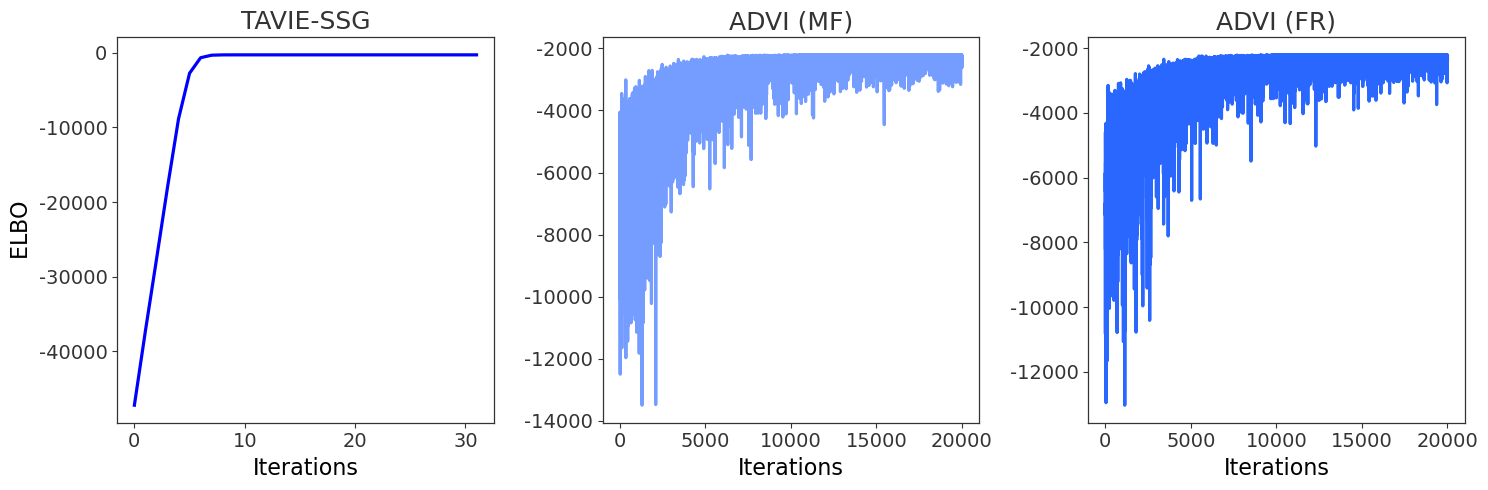

In [ ]:
# ==== Experiment settings ====
n = 2000
total_p = 9 # total_p = p + 1
p = 8
tau2_true = 3.0
df = 5

# True beta vector
beta_true = np.random.normal(loc=0.0, scale=1.0, size=p+1)

# Prior for full‐cov BBVI
Sigma_prior = np.eye(p + 1)
a, b = 0.025, 0.025

# Initialize TAVIE once
student_tavie_model = TAVIE_loc_scale(family="student", fit_intercept=True)

X = np.random.normal(size=(n, p))
X_bbvi = np.column_stack((np.ones(n), X))
error =  np.random.standard_t(size = n, df = df) * 1/np.sqrt(tau2_true)
y = beta_true[0] + X @ beta_true[1:len(beta_true)] + error

# ---- TAVIE ----
student_tavie_model.fit(X, y, nu=df, verbose=False)

# ADVI mean-field estimator
res2 = BBVI_student_patience_best(X_bbvi, y, nu=df, a0=a, b0=b, lr=1e-3, patience=1e4, tol=1e-9, verbose=False)

# ADVI full-rank estimator
res3 = BBVI_student_fullcov_AdamW_best(X_bbvi, y, nu=df, Sigma_prior=Sigma_prior, a0=a, b0=b, lr=1e-3, patience=1e4,
                                                    tol=1e-9, verbose=False)

tavie_elbo = student_tavie_model.get_elbo()
advi_mf_elbo = res2['elbo_hist']
advi_fr_elbo = res3['elbo_hist']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')
colors = [
    'blue',  # bright aqua
    '#759DFF',  # turquoise blue
    '#2967FF'   # strong deep blue
]
axes[0].plot(tavie_elbo, color=colors[0], linewidth=2.3)
axes[0].set_title(r'TAVIE-SSG', fontsize=18, color='#333333')
axes[0].set_xlabel('Iterations', fontsize=16)
axes[0].set_ylabel(r'$\mathsf{ELBO}$', fontsize=16)

axes[1].plot(advi_mf_elbo, color=colors[1], linewidth=2.3)
axes[1].set_title(r'ADVI (MF)', fontsize=18, color='#333333')
axes[1].set_xlabel('Iterations', fontsize=16)

axes[2].plot(advi_fr_elbo, color=colors[2], linewidth=2.3)
axes[2].set_title(r'ADVI (FR)', fontsize=18, color='#333333')
axes[2].set_xlabel('Iterations', fontsize=16)

# --- Shared styling ---
for ax in axes:
    #ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(0.9)
    ax.tick_params(axis='both', labelsize=14, colors='#333333')

plt.tight_layout()
#fig.suptitle(r'$\mathsf{ELBO}$ Convergence Trajectories', fontsize=17, color='#333333', y=1.03)

# Save high-resolution figure
fig.savefig(f'results_compete/plots/Student_ELBO_n_{n}_p_{p}.pdf',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
